# Fit functions with pyoperon

This notebook mirrors `fit_functions.ipynb`, but instead of the LLM-driven genetic search it fits each function with [pyoperon](https://github.com/heal-research/pyoperon)'s `SymbolicRegressor`.

Note: the `pyoperon` binary shipped in the `~/llm` venv had a broken `@rpath` to `libz`/`libzstd`; a `/usr/lib` rpath was added (and the lib re-signed ad-hoc) so a plain `import pyoperon` works. If you reinstall pyoperon you may need to re-apply that fix or set `DYLD_FALLBACK_LIBRARY_PATH=/usr/lib` before launching the kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyoperon.sklearn import SymbolicRegressor

In [2]:
funcs = [lambda x: (np.abs(np.sin(x))**0.5),
            lambda x: np.exp(( 1.83169 + (-3.35509 * (1 / x)))),
            lambda x: (x**3.),
            lambda x: ((1.44439 + (x**0.5)) * (np.pi + np.log(x))),
            lambda x: (3.09529 * (x**3.)),
            lambda x: ((np.pi + (x**3.))**2),
            lambda x: (51.2288 * np.cos((1.18219 * x))),
            lambda x: (-55.0512 * (1.0+(x**0.5))),
            lambda x: x,
            lambda x: (-0.0126997 + np.exp(np.cos(x))),
            lambda x: (1.54251 + (-1. * x)),
            lambda x: ((np.exp(2*x))),
            lambda x: (4.01209 + np.exp(x)),
            lambda x: ((-1. * np.pi) + (0.729202 * (x**0.5))),
            lambda x: (1.99594 + x + (-3. * ( x**3.))),
            lambda x: np.log(x+1),
            lambda x: np.sin(np.log((4.1746 * (1 / x)))),
            lambda x: (4.67315 + np.cos(np.exp(x))),
            lambda x: np.exp((-x))+2*np.exp(-3*x),
            lambda x: ((x**-3.) * np.sin(x))
            ]

print(len(funcs))

20


In [3]:
def make_regressor():
    return SymbolicRegressor(
        allowed_symbols='add,sub,mul,div,pow,exp,sin,constant,variable',
        offspring_generator='basic',
        optimizer_iterations=10,
        max_length=30,
        initialization_method='btc',
        n_threads=8,
        objectives=['rmse', 'length'],
        epsilon=1e-3,
        random_state=None,
        reinserter='keep-best',
        max_evaluations=int(1e12),
        symbolic_mode=False,
        max_time=10,
        generations=int(1e12),
    )

# Run 1

## Search

Function 0


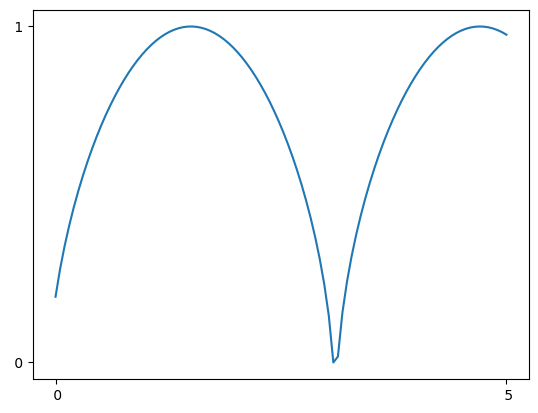

(0.73266 + (0.08781 * (0.23972 * X1)))
Function 1


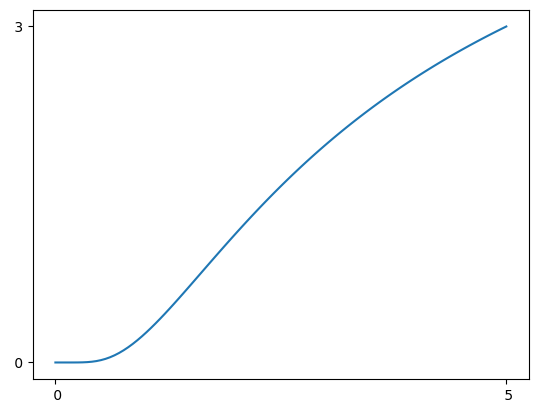

((-0.35340) + ((-15837290.00000) * ((-0.00000) * X1)))
Function 2


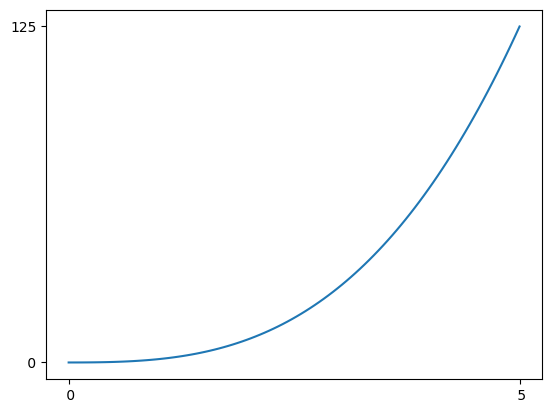

(0.00000 + ((-7.49907) * (((-0.51089) * X1) ^ 3.00000)))
Function 3


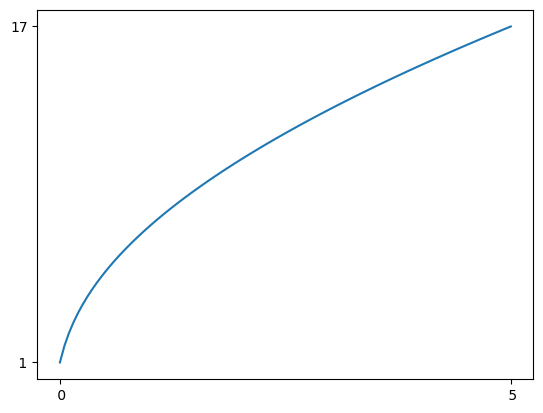

((-1.40991) + (1.15469 * ((91.84975 * X1) ^ 0.45539)))
Function 4


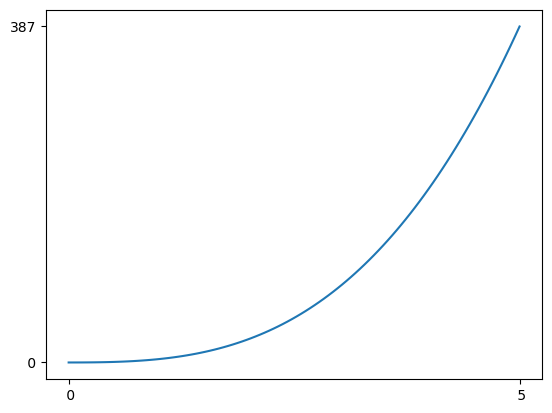

((-0.00000) + ((-11.35496) * (((-0.64839) * X1) ^ 3.00000)))
Function 5


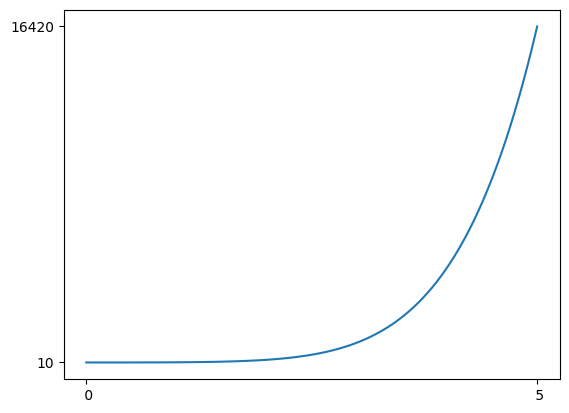

(0.00007 + (1.00000 * (((1.84527 * X1) ^ 3.00000) + (9.86959 + ((1.00000 * X1) ^ 6.00000)))))
Function 6


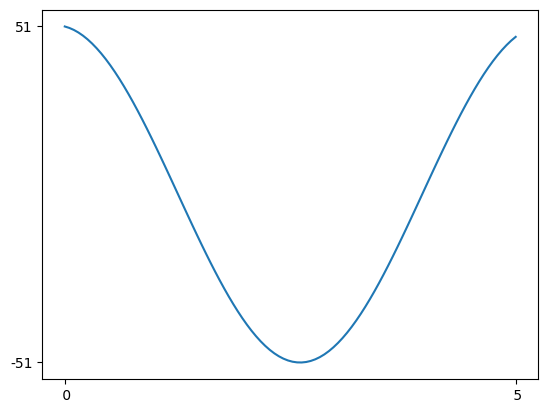

((-0.00000) + (51.22880 * sin((1.57080 - (1.18219 * X1)))))
Function 7


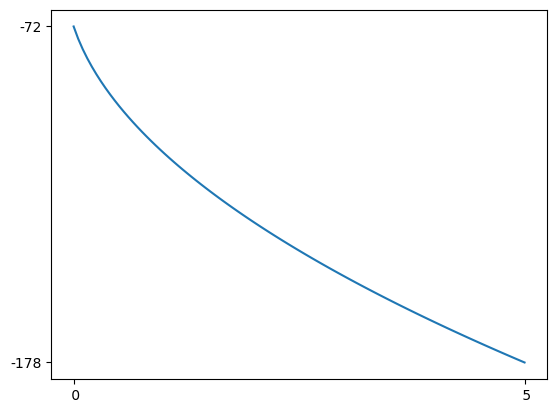

((-55.05120) + ((-3.85609) * ((203.81697 * X1) ^ 0.50000)))
Function 8


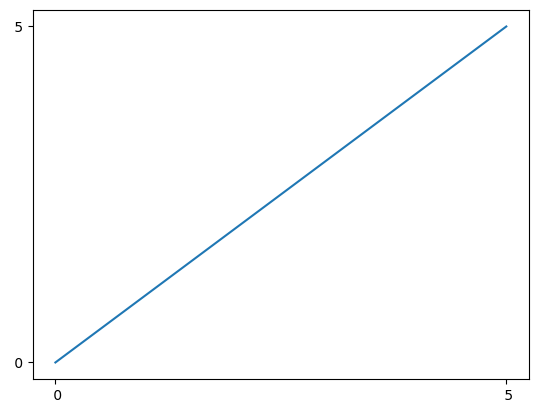

(1.00000 * X1)
Function 9


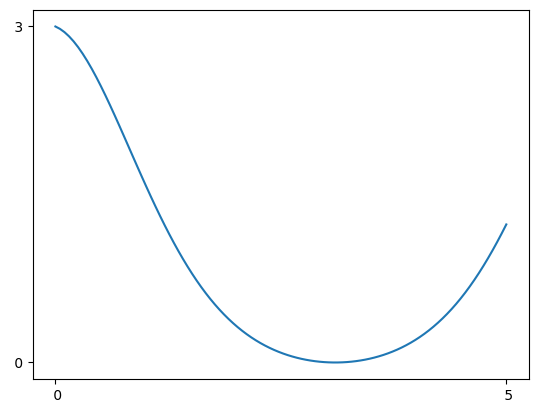

(2.94987 + ((-2.66489) * sin((0.49523 * X1))))
Function 10


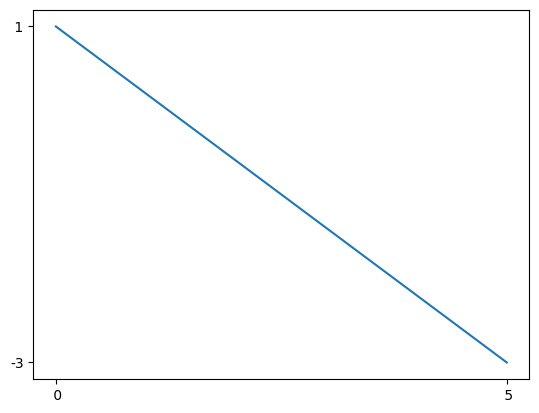

(1.54251 + (1.29236 * ((-0.77378) * X1)))
Function 11


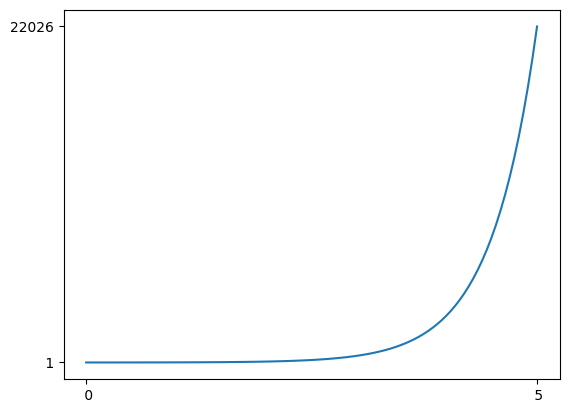

((-0.00024) + (1.00000 * exp((2.00000 * X1))))
Function 12


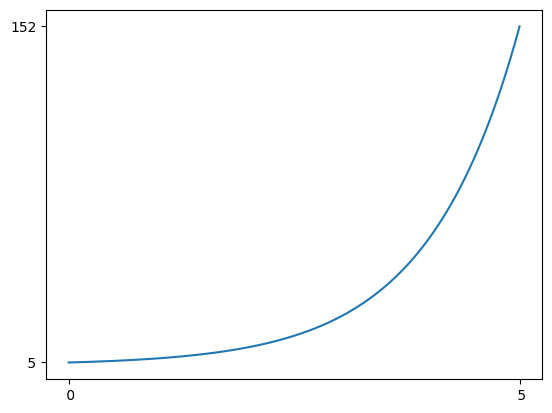

(4.01209 + (1.00000 * exp((1.00000 * X1))))
Function 13


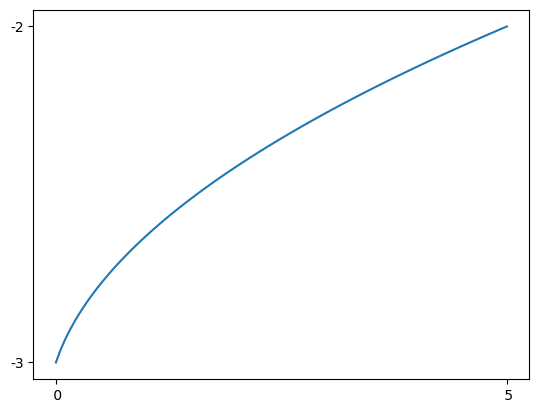

((-2.68595) + ((-0.75725) * ((-0.33591) * X1)))
Function 14


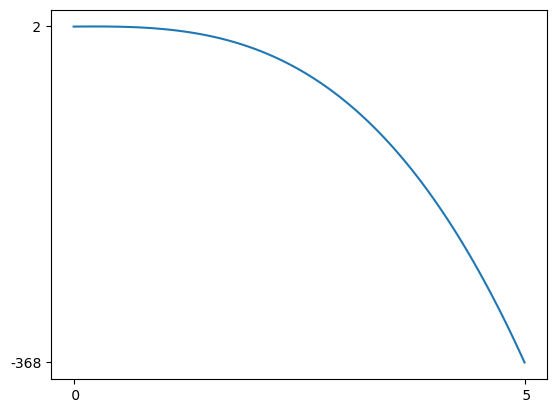

(2.75066 + ((-2.53116) * ((1.03506 * X1) ^ 3.03415)))
Function 15


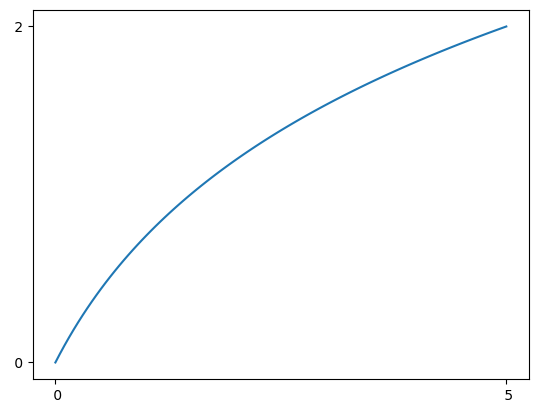

(0.36186 + (0.76142 * (0.41636 * X1)))
Function 16


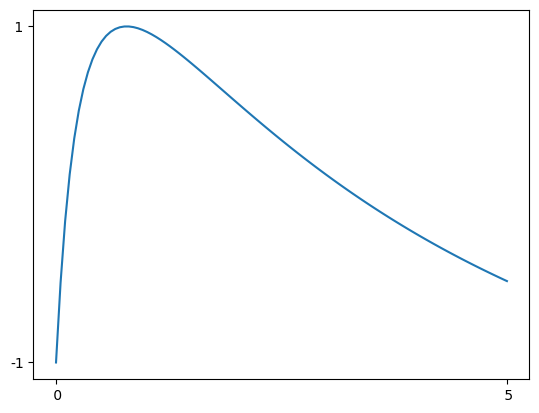

(0.95869 + ((-3.52041) * (0.06042 * X1)))
Function 17


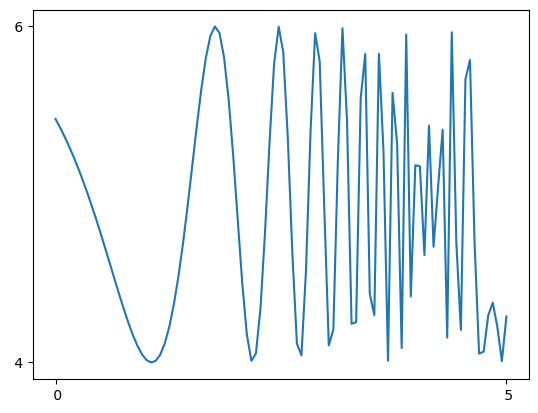

(4.54750 + ((-0.00077) * (1.20331 * X1)))
Function 18


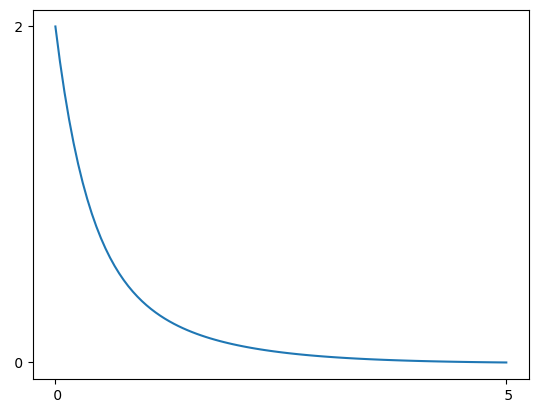

(0.03798 + (2.70262 * exp(((-1.85786) * X1))))
Function 19


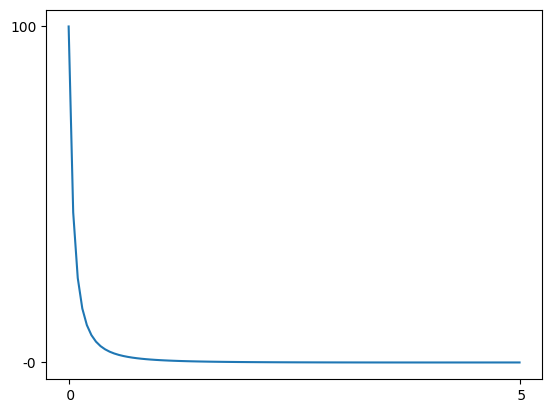

((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))


In [4]:
xVals = np.linspace(0.1, 5, 100)
X = xVals.reshape(-1, 1)
count = 0
res_list = []

for func in funcs:
    print(f"Function {count}")
    count += 1
    y = func(xVals)

    fig, ax = plt.subplots()
    plt.xticks([xVals[0], xVals[-1]], ['%2.f' % xVals[0], '%2.f' % xVals[-1]])
    plt.yticks([min(y), max(y)], ['%2.f' % min(y), '%2.f' % max(y)])
    ax.plot(xVals, y)
    plt.show()

    reg = make_regressor()
    reg.fit(X, y)
    res_list.append(reg)
    print(reg.get_model_string(reg.model_, 5))

## Compare

Function 0
(0.73266 + (0.08781 * (0.23972 * X1)))
RMSE: 0.22016077606018236


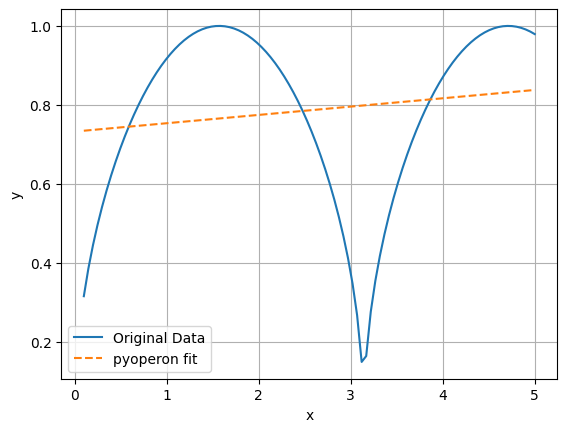

Function 1
((-0.35340) + ((-15837290.00000) * ((-0.00000) * X1)))
RMSE: 0.11851216978068621


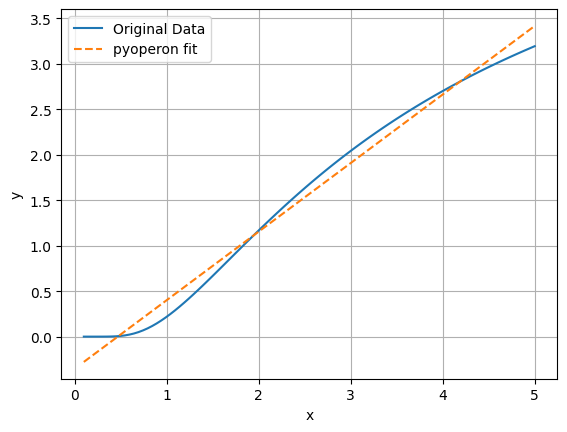

Function 2
(0.00000 + ((-7.49907) * (((-0.51089) * X1) ^ 3.00000)))
RMSE: 5.6589537216601916e-06


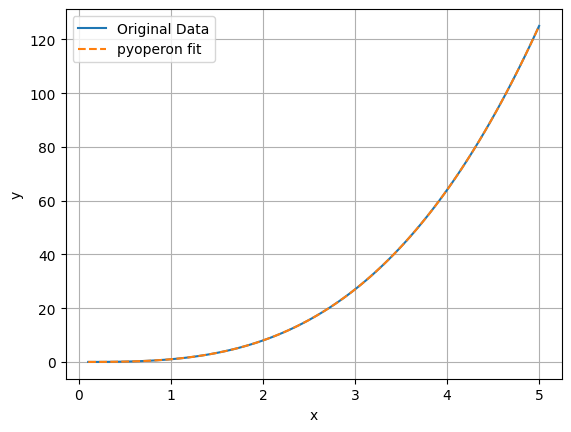

Function 3
((-1.40991) + (1.15469 * ((91.84975 * X1) ^ 0.45539)))
RMSE: 0.050216055490473685


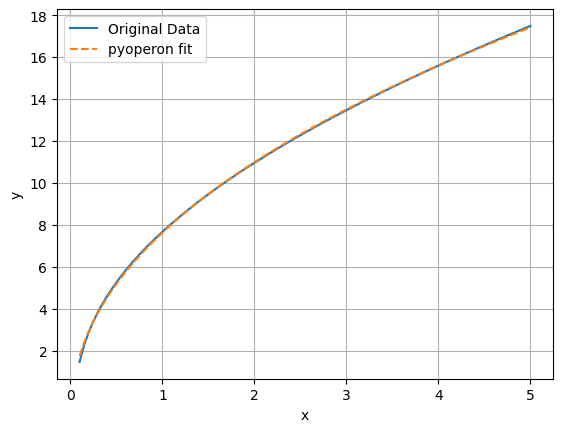

Function 4
((-0.00000) + ((-11.35496) * (((-0.64839) * X1) ^ 3.00000)))
RMSE: 1.397047498867831e-05


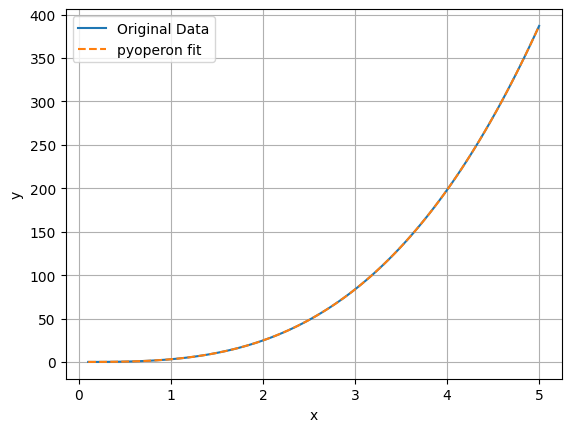

Function 5
(0.00007 + (1.00000 * (((1.84527 * X1) ^ 3.00000) + (9.86959 + ((1.00000 * X1) ^ 6.00000)))))
RMSE: 0.000729803120413635


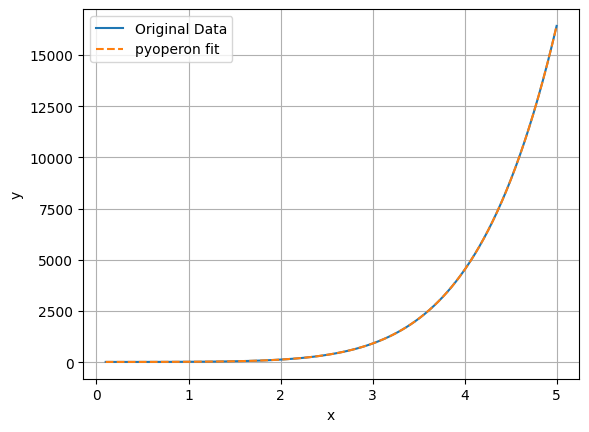

Function 6
((-0.00000) + (51.22880 * sin((1.57080 - (1.18219 * X1)))))
RMSE: 6.6774019337659295e-06


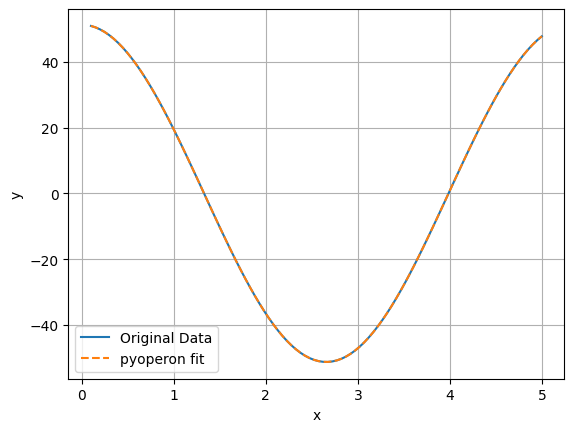

Function 7
((-55.05120) + ((-3.85609) * ((203.81697 * X1) ^ 0.50000)))
RMSE: 4.6245665664121796e-06


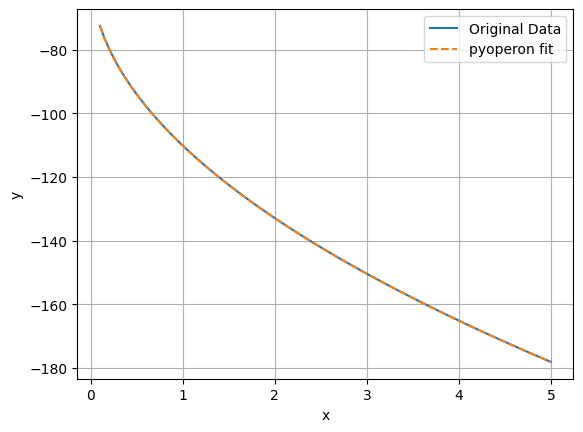

Function 8
(1.00000 * X1)
RMSE: 7.714602400139341e-08


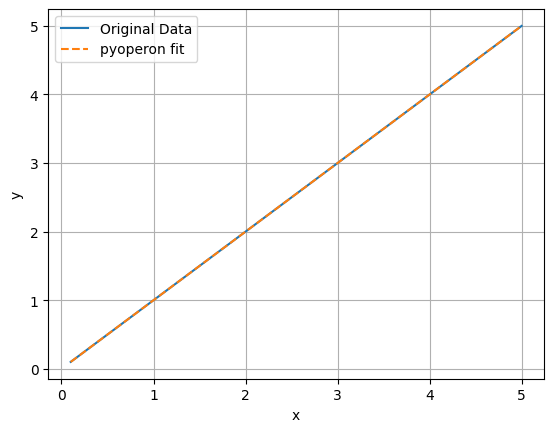

Function 9
(2.94987 + ((-2.66489) * sin((0.49523 * X1))))
RMSE: 0.05775438096455088


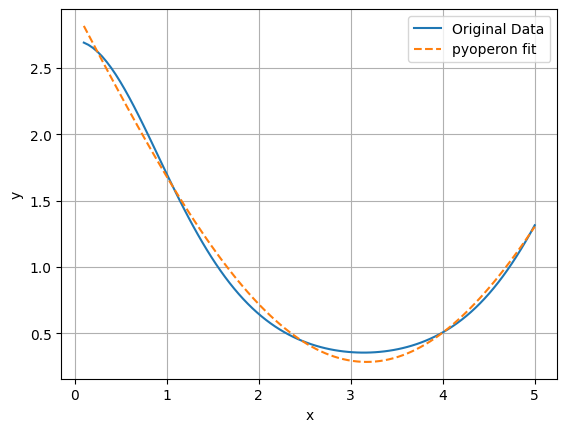

Function 10
(1.54251 + (1.29236 * ((-0.77378) * X1)))
RMSE: 1.145722316001232e-07


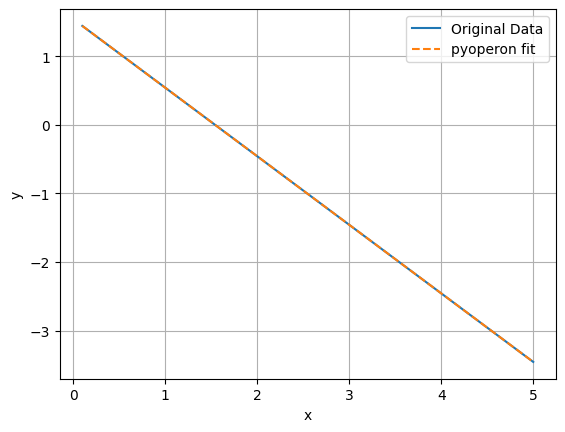

Function 11
((-0.00024) + (1.00000 * exp((2.00000 * X1))))
RMSE: 0.001300576678235682


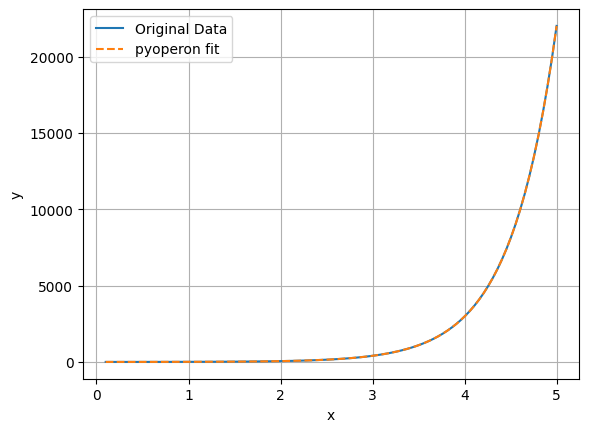

Function 12
(4.01209 + (1.00000 * exp((1.00000 * X1))))
RMSE: 8.071095587708372e-06


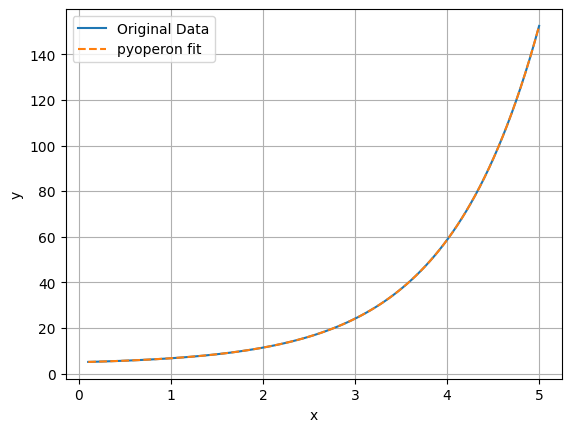

Function 13
((-2.68595) + ((-0.75725) * ((-0.33591) * X1)))
RMSE: 0.06643416078098817


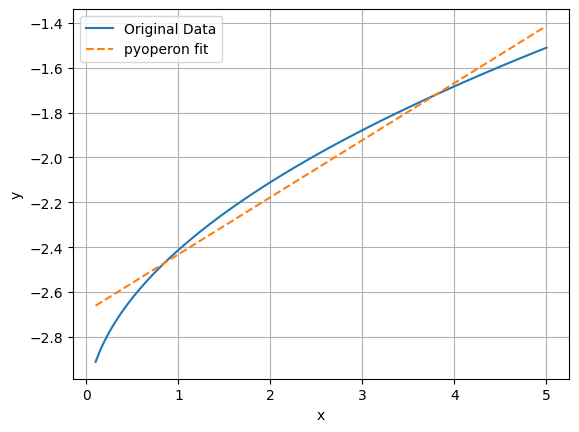

Function 14
(2.75066 + ((-2.53116) * ((1.03506 * X1) ^ 3.03415)))
RMSE: 0.2198108213131023


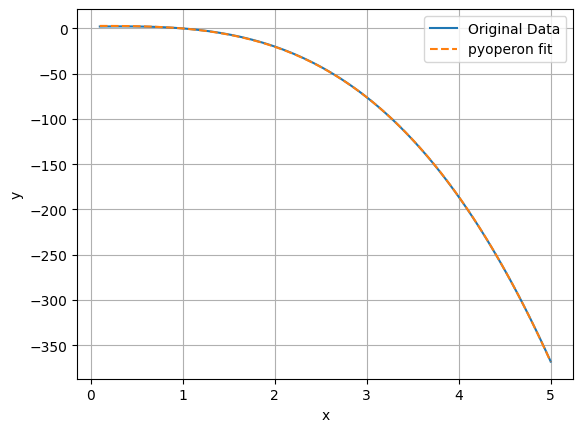

Function 15
(0.36186 + (0.76142 * (0.41636 * X1)))
RMSE: 0.09723490631750276


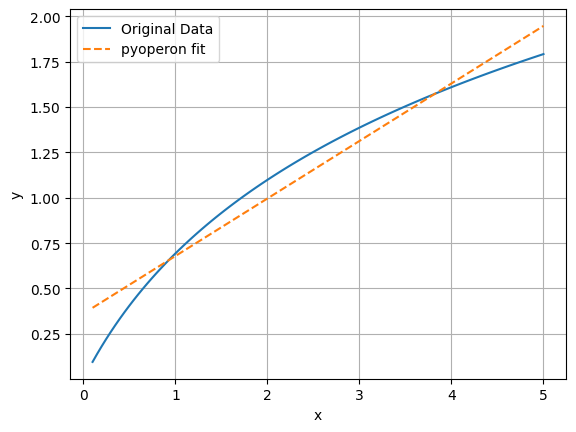

Function 16
(0.95869 + ((-3.52041) * (0.06042 * X1)))
RMSE: 0.250293283462203


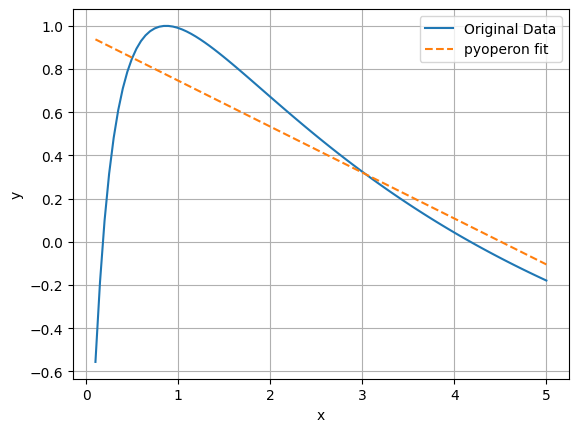

Function 17
(4.54750 + ((-0.00077) * (1.20331 * X1)))
RMSE: 0.6577035685985569


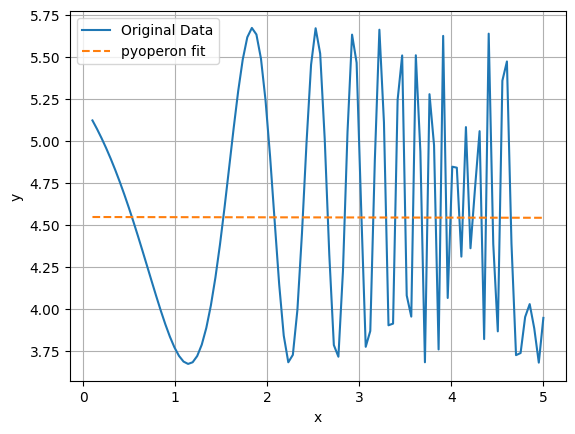

Function 18
(0.03798 + (2.70262 * exp(((-1.85786) * X1))))
RMSE: 0.029679754325598343


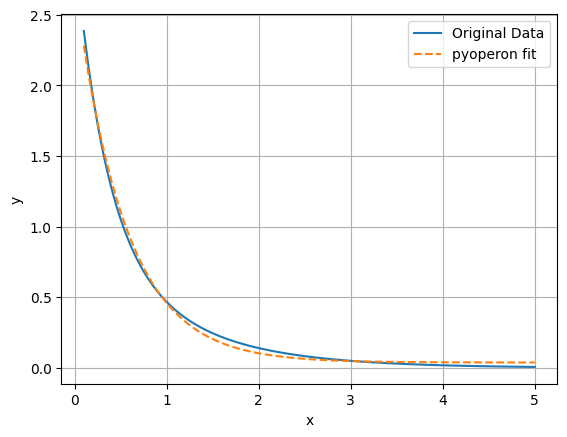

Function 19
((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))
RMSE: 0.03216693851804409


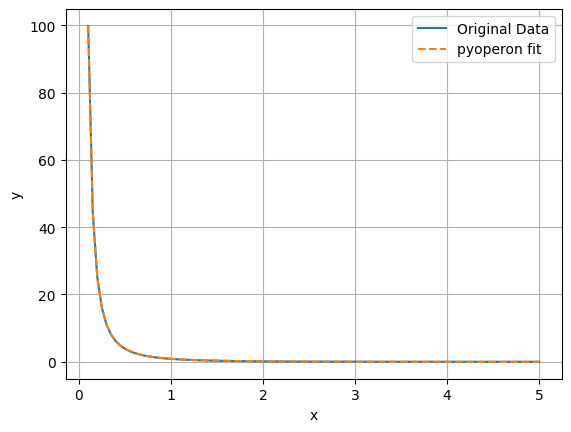

In [5]:
for index in range(len(res_list)):
    print(f"Function {index}")
    y = funcs[index](xVals)
    reg = res_list[index]

    y_pred = reg.predict(X)
    print(reg.get_model_string(reg.model_, 5))
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    print(f"RMSE: {rmse}")

    # Plot the original data
    plt.plot(xVals, y, label='Original Data')

    # Plot the pyoperon fit
    plt.plot(xVals, y_pred, label='pyoperon fit', linestyle='--')

    # Add labels and legend
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run 2

## Search

In [6]:
funcs2 = [funcs[0],
          funcs[1],
          funcs[3],
          funcs[5],
          funcs[9],
          funcs[16],
          funcs[18],
          funcs[19]
          ]

Function 0


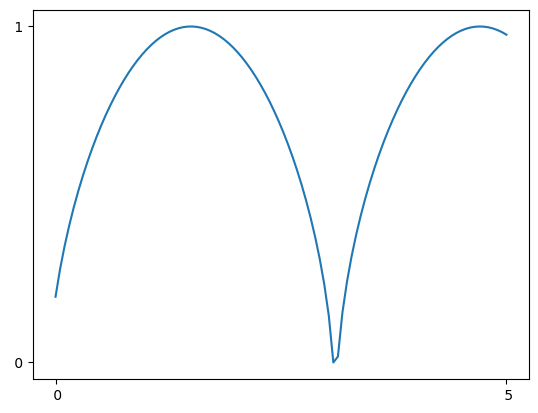

(0.73266 + (0.08781 * (0.23972 * X1)))
Function 1


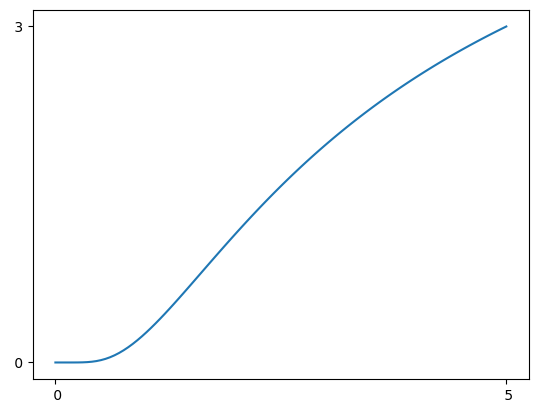

((-0.35340) + (100877408.00000 * (0.00000 * X1)))
Function 2


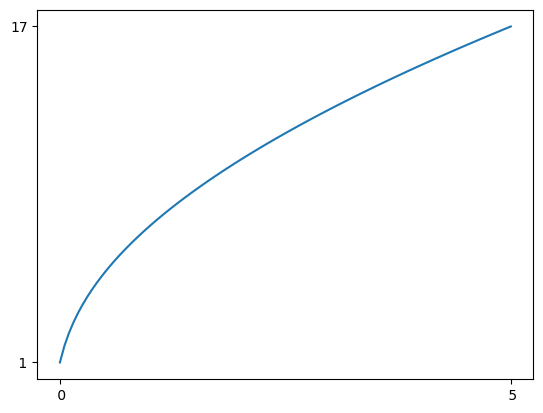

(20.06561 + ((-18.00779) * exp(((-0.34939) * X1))))
Function 3


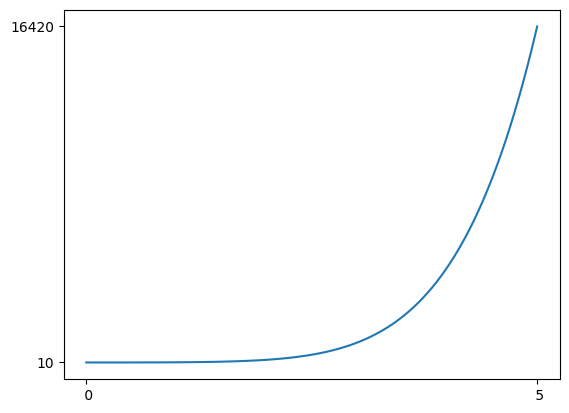

(0.00001 + (1.00000 * ((3.14158 + ((1.00000 * X1) ^ 3.00000)) ^ 2.00000)))
Function 4


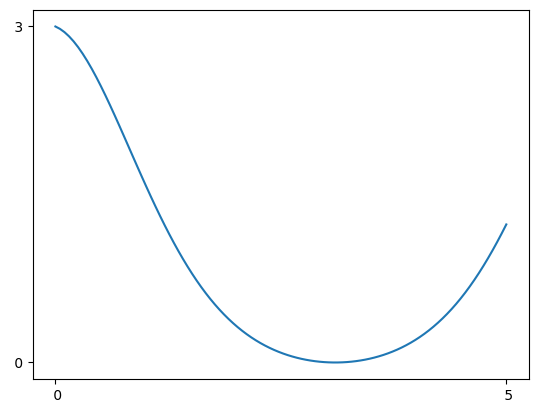

(2.94987 + (2.66489 * sin(((-0.49523) * X1))))
Function 5


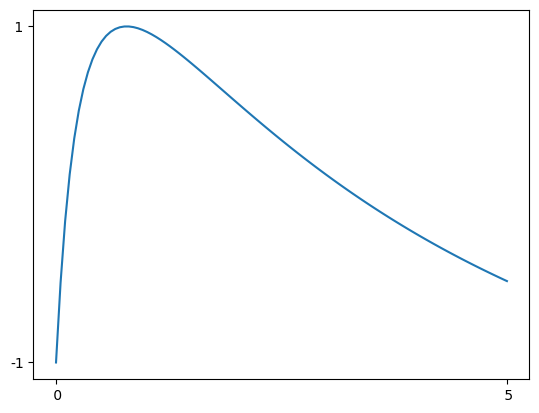

(0.95869 + (14.44794 * ((-0.01472) * X1)))
Function 6


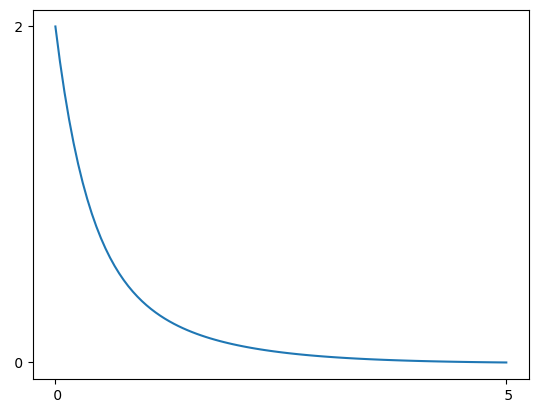

(0.03798 + (2.70267 * exp(((-1.85792) * X1))))
Function 7


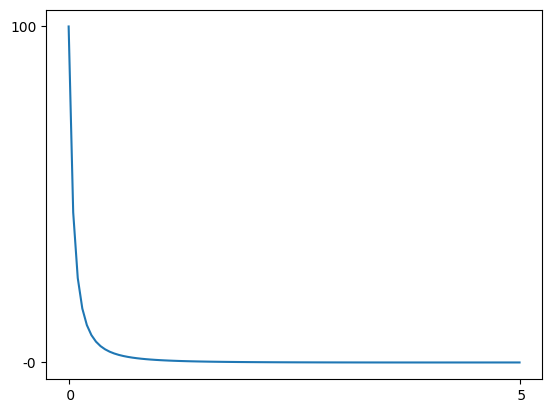

((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))


In [7]:
xVals = np.linspace(0.1, 5, 100)
X = xVals.reshape(-1, 1)
count = 0
res_list_2 = []

for func in funcs2:
    print(f"Function {count}")
    count += 1
    y = func(xVals)

    fig, ax = plt.subplots()
    plt.xticks([xVals[0], xVals[-1]], ['%2.f' % xVals[0], '%2.f' % xVals[-1]])
    plt.yticks([min(y), max(y)], ['%2.f' % min(y), '%2.f' % max(y)])
    ax.plot(xVals, y)
    plt.show()

    reg = make_regressor()
    reg.fit(X, y)
    res_list_2.append(reg)
    print(reg.get_model_string(reg.model_, 5))

## Compare

Function 0
(0.73266 + (0.08781 * (0.23972 * X1)))
RMSE: 0.22016077821545757


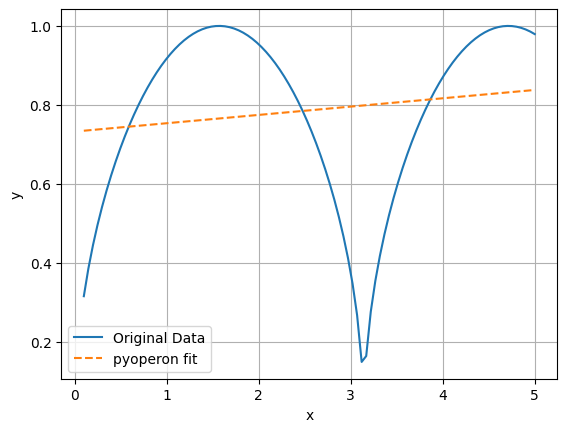

Function 1
((-0.35340) + (100877408.00000 * (0.00000 * X1)))
RMSE: 0.11851217590769222


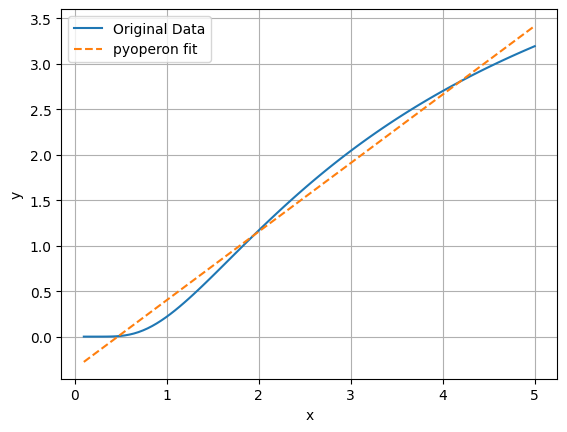

Function 2
(20.06561 + ((-18.00779) * exp(((-0.34939) * X1))))
RMSE: 0.2862375179698918


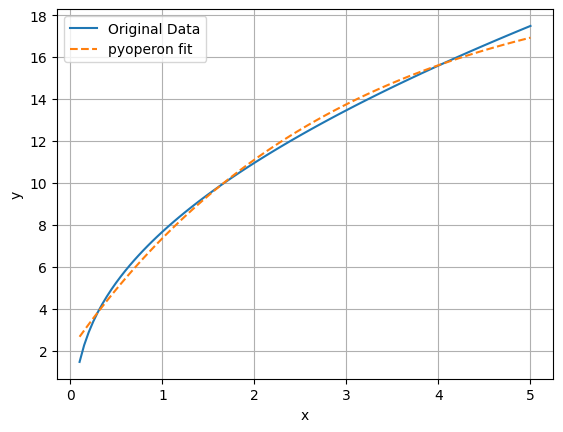

Function 3
(0.00001 + (1.00000 * ((3.14158 + ((1.00000 * X1) ^ 3.00000)) ^ 2.00000)))
RMSE: 0.0006516813706708456


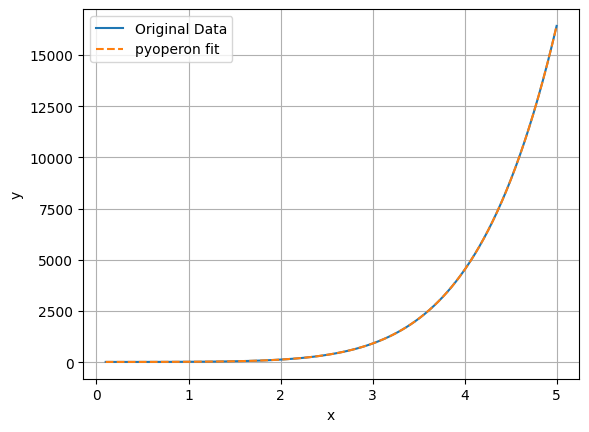

Function 4
(2.94987 + (2.66489 * sin(((-0.49523) * X1))))
RMSE: 0.05775438096455088


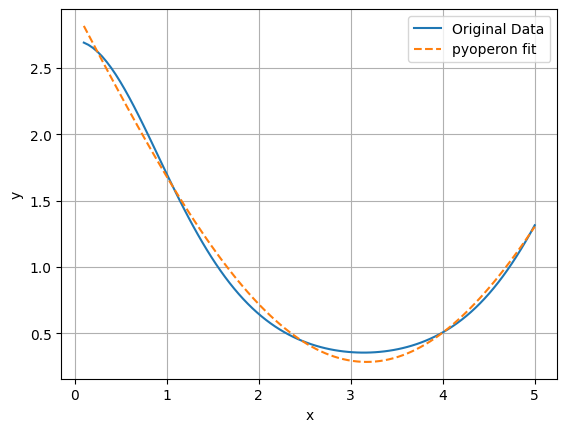

Function 5
(0.95869 + (14.44794 * ((-0.01472) * X1)))
RMSE: 0.2502932833107384


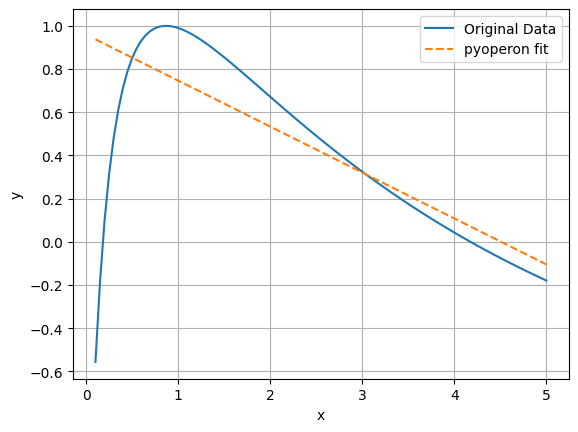

Function 6
(0.03798 + (2.70267 * exp(((-1.85792) * X1))))
RMSE: 0.029679750612733723


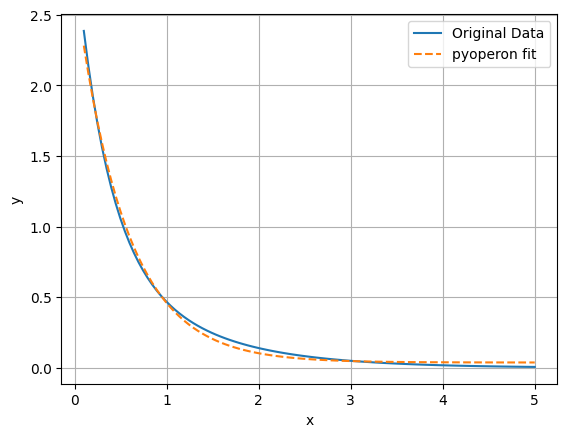

Function 7
((-0.10466) + (1.00000 * ((1.00682 * X1) ^ (-2.00579))))
RMSE: 0.03216693851804409


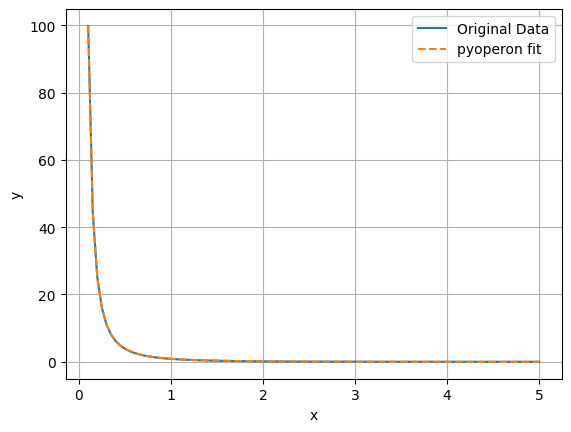

In [8]:
for index in range(len(res_list_2)):
    print(f"Function {index}")
    y = funcs2[index](xVals)
    reg = res_list_2[index]

    y_pred = reg.predict(X)
    print(reg.get_model_string(reg.model_, 5))
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    print(f"RMSE: {rmse}")

    # Plot the original data
    plt.plot(xVals, y, label='Original Data')

    # Plot the pyoperon fit
    plt.plot(xVals, y_pred, label='pyoperon fit', linestyle='--')

    # Add labels and legend
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()